In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import keras
from keras.layers import Input, Dense, Layer
from keras.models import Model
from keras.datasets import mnist
import tensorflow as tf

In [24]:
batch_size=100
original_dim=784
latent_dim=2
intermediate_dim=256
nb_epoch=5
epsilon_std=1.0

In [25]:
class Sampling(Layer):
    def call(self,inputs):
        z_mean,z_log_var=inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon =  tf.random.normal(shape=(batch,dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon 

In [26]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder, original_dim, name="vae", **kwargs):
          super().__init__(**kwargs)
          self.encoder=encoder
          self.decoder=decoder
          self.original_dim = original_dim
          
          self.total_loss_tracker = keras.metrics.Mean(name="loss")
          self.recon_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
          self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property 
    def metrics(self):
        return [ self.total_loss_tracker,
                self.recon_loss_tracker,
                self.kl_loss_tracker]
    
    def _compute_losses(self,data):
        x =  data
        z_mean ,  z_log_var, z = self.encoder(x , training = True)
        reconstruction = self.decoder( z , training = True)
        recon_loss = self.original_dim *  tf.reduce_mean(
            keras.losses.binary_crossentropy(x,reconstruction))
        
        kl_loss = -0.5 * tf.reduce_sum(
           1 + z_log_var -  tf.square(z_mean) - tf.exp(z_log_var),axis=-1)
        
        kl_loss = tf.reduce_mean(kl_loss)
        total_loss = recon_loss + kl_loss
        return total_loss, recon_loss, kl_loss
    
    def train_step(self,data):
        if isinstance(data,tuple):
            data= data[0]
        with tf.GradientTape() as tape:
            total_loss, recon_loss, kl_loss = self._compute_losses(data)
        grads =  tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads,self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self,data):
        if isinstance(data,tuple):
            data =  data[0]
        total_loss, recon_loss, kl_loss = self._compute_losses(data)
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return{m.name: m.result() for m in self.metrics}
      

In [27]:
encoder_inputs = keras.Input(shape=(original_dim,), name="encoder_input")

h = keras.layers.Dense(intermediate_dim, activation='relu')(encoder_inputs)

z_mean = keras.layers.Dense(latent_dim, name="z_mean")(h)
z_log_var = keras.layers.Dense(latent_dim, name="z_log_var")(h)

z = Sampling()([z_mean, z_log_var])

encoder = keras.Model(encoder_inputs,
    [z_mean, z_log_var, z],name="encoder"
)
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 256)       │    200,960 │ encoder_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        514 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        514 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling_2          │ (None, 2)         │          0 │ z_mean[0][0],     │
│ (Sampling)          │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 201,988 (789.02 KB)

 Trainable params: 201,988 (789.02 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
decoder_inputs=Input(shape=(latent_dim,),name="decoder_input")
h_decoded = Dense(intermediate_dim,activation='relu')(decoder_inputs)
x_decoded_mean =  Dense(original_dim, activation = 'sigmoid')(h_decoded)

decoder = Model(decoder_inputs, x_decoded_mean, name="decoder")
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 202,256 (790.06 KB)

 Trainable params: 202,256 (790.06 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
vae=VAE(encoder,decoder,original_dim)
print("VAE",vae)

VAE <VAE name=vae_2, built=False>


In [30]:
(x_train,y_train),(x_test,y_test) = mnist.load_data()

x_train = x_train.astype('float32')/255
x_test = x_test.astype('float32')/255

x_train = x_train.reshape((len(x_train),np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test),np.prod(x_test.shape[1:])))

print('x_train shape:', x_train.shape)
print('x_test shape:', x_test.shape)

x_train shape: (60000, 784)
x_test shape: (10000, 784)


In [31]:
vae.compile(optimizer=keras.optimizers.Adam())

vae.fit(
    x_train,
    epochs=30,
    batch_size=128,
    validation_data=(x_test, None)
)


Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - kl_loss: 14.7458 - loss: 251.1189 - reconstruction_loss: 236.3730 - val_kl_loss: 5.2813 - val_loss: 179.3526 - val_reconstruction_loss: 174.0712
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - kl_loss: 4.9311 - loss: 176.4629 - reconstruction_loss: 171.5317 - val_kl_loss: 4.8907 - val_loss: 170.4131 - val_reconstruction_loss: 165.5224
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - kl_loss: 4.8388 - loss: 170.2111 - reconstruction_loss: 165.3723 - val_kl_loss: 4.9468 - val_loss: 167.9701 - val_reconstruction_loss: 163.0233
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - kl_loss: 4.8942 - loss: 167.7434 - reconstruction_loss: 162.8492 - val_kl_loss: 5.0355 - val_loss: 165.9637 - val_reconstruction_loss: 160.9282
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - kl_loss: 5.0018 - loss: 165.9379 - reconstruction_loss: 160.9361 - val_kl_loss: 5.0467 - val_loss: 164.3538 - val_reconstruction_loss: 159.3071
Epoch 6/

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


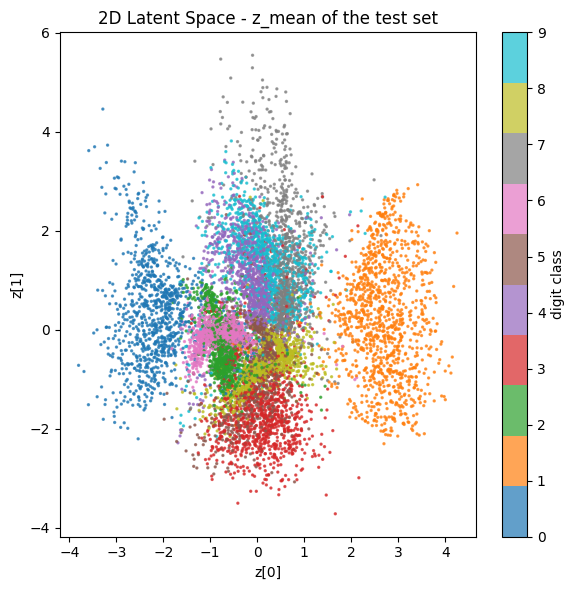

In [32]:
z_mean_model = Model(encoder.input, encoder.get_layer("z_mean").output)

x_test_encoded = z_mean_model.predict(x_test)

plt.figure(figsize=(6, 6))
plt.scatter(
    x_test_encoded[:, 0],
    x_test_encoded[:, 1],
    c=y_test,
    cmap='tab10',
    s=2,
    alpha=0.7
)

plt.colorbar(label='digit class')
plt.xlabel('z[0]')
plt.ylabel('z[1]')
plt.title('2D Latent Space - z_mean of the test set')
plt.tight_layout()
plt.show()

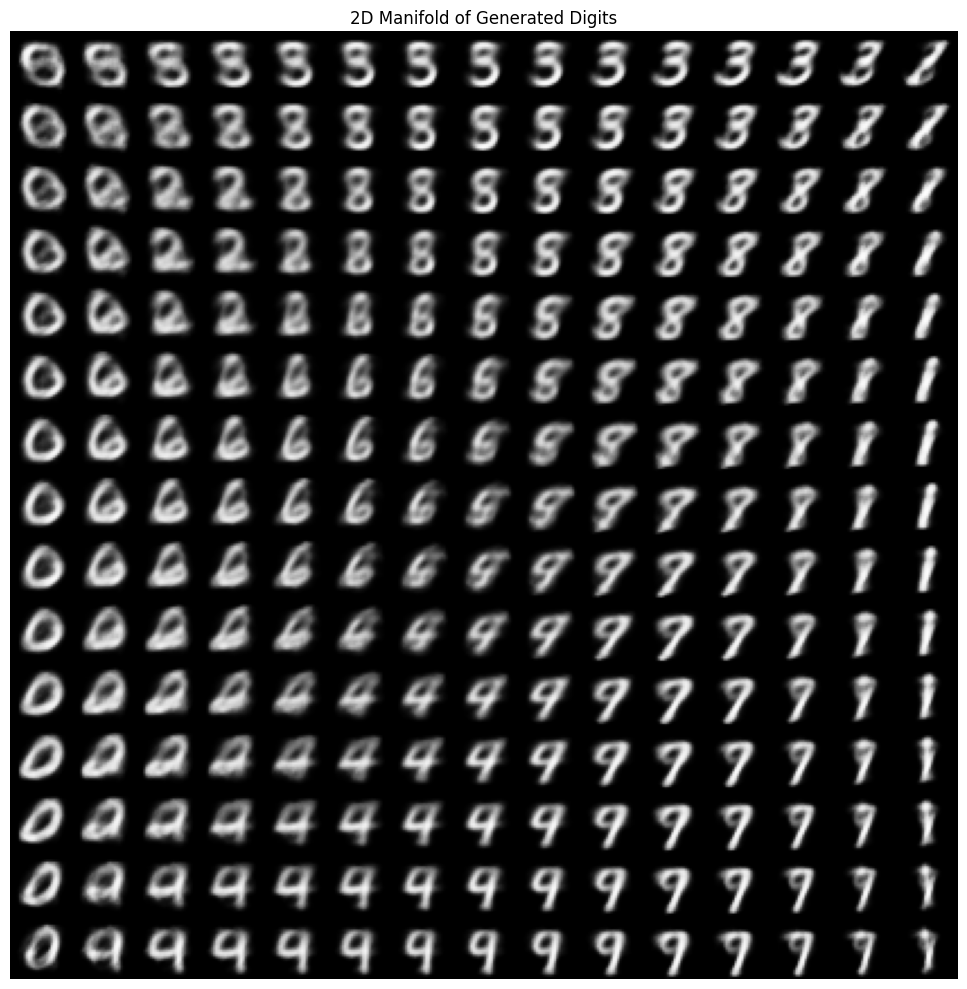

In [33]:
n = 15
digit_size = 28
figure = np.zeros((digit_size * n, digit_size * n))

grid_x  = norm.ppf(np.linspace(0.05,0.95,n))
grid_y  = norm.ppf(np.linspace(0.05,0.95,n))

for i , yi in enumerate(grid_y):
    for j , xi in enumerate(grid_x):
        z_sample = np.array([[xi,yi]])
        x_decoded =  decoder.predict(z_sample,verbose=0)
        digit = x_decoded[0].reshape(digit_size,digit_size)
        figure[i * digit_size : ( i + 1 ) * digit_size,
               j * digit_size : ( j + 1 ) * digit_size ] = digit
        
plt.figure ( figsize = ( 10 , 10 ))
plt.imshow(figure,cmap='Grays_r')
plt.title("2D Manifold of Generated Digits")
plt.axis('off')
plt.tight_layout()
plt.show()